# Challenge 03 — Analítica Multidimensional
### TechLogistics S.A. · Metodología CRISP-DM · EAFIT — Maestría en Ciencia de los Datos

> **Nota sobre la numeración.** El PDF entregado por el docente se titula "Challenge 02",
> pero corresponde al **workshop de la Lecture 03**; unificamos la etiqueta a **Challenge 03**
> (el "02" fue un error de numeración en el documento fuente).

Este notebook resuelve, de principio a fin, el reto de **analítica multidimensional**
sobre dos dominios operativos de TechLogistics:

- **Agroindustria / Clima** (`agro_*`) — red de sensores tipo *mesh* en el Oriente Antioqueño.
- **Energía / Economía** (`ener_*`) — red de *despacho* eléctrico.

Se cubren cuatro fases CRISP-DM: (1) *Data Understanding* + geo-visualización,
(2) procesamiento de señales y filtrado, (3) grafos y topología de red, y
(4) modelado y decisiones de negocio.

---
## Supuestos metodológicos (declarados explícitamente)

1. **Existencia de señal *clean*.** El brief asumía que *solo* se entregaron los archivos
   `*_noise`. Sin embargo, los archivos `agro_clean.csv` y `ener_clean.csv` **sí existen**
   en `data/`. Por rigor usamos esa **señal limpia real como referencia (ground truth)**
   para SNR y RMSE, en lugar de estimarla. Aun así construimos la versión *denoised*
   (Butterworth / media móvil) para demostrar el pipeline de filtrado y para el caso en
   que la referencia no estuviera disponible.
2. **Sin timestamp.** Los CSV no traen columna temporal. Creamos un `DatetimeIndex`
   **sintético horario** (`freq='h'`, inicio fijo `2023-01-01`) para todo el análisis de
   series de tiempo. Es un supuesto: asume muestreo equiespaciado de 1 registro/hora.
3. **Reproducibilidad.** Fijamos la semilla de NumPy (`seed=42`).
4. **Diccionario de variables.** Interpretamos cada variable según el diccionario provisto
   (no se inventan significados).

### Bootstrap (Google Colab / entornos sin el repo clonado)

Este notebook importa código desde el paquete local `src/` y lee los CSV de `data/`. En **Google Colab** (o cualquier máquina sin el repositorio) esos archivos no existen y `from src import ...` fallaría. La siguiente celda lo resuelve automáticamente: si no encuentra el proyecto, **clona el repositorio de GitHub**, entra en él e instala las dependencias que Colab no trae (p. ej. `pmdarima`). En ejecución local no hace nada.

In [ ]:
# --- Bootstrap portátil: hace que el notebook corra igual en local y en Colab ---
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/santiagovelcasallas/Challenge03_techlogistics-GomezVelez.git"
REPO_DIR = "Challenge03_techlogistics-GomezVelez"

def _project_here(p) -> bool:
    p = Path(p)
    return (p / "src").is_dir() and (p / "data").is_dir()

# ¿El proyecto ya está disponible (ejecución local dentro del repo)?
_found = any(_project_here(p) for p in [Path.cwd(), *Path.cwd().parents])

if not _found:
    print("Proyecto no encontrado localmente -> clonando desde GitHub (modo Colab)...")
    if not Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    # Dependencias que Colab no incluye por defecto (best-effort: el modelo P3
    # tiene fallback si pmdarima no queda disponible).
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pmdarima", "contextily"], check=False)
    print("Repositorio listo. Directorio de trabajo:", Path.cwd())
else:
    print("Proyecto encontrado localmente. Directorio de trabajo:", Path.cwd())

### Configuración del entorno y utilidades reutilizables (`src/`)

In [1]:
import sys
from pathlib import Path

# --- Localizar la raíz del proyecto de forma robusta (busca requirements.txt) ---
def find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "requirements.txt").exists() and (cand / "src").exists():
            return cand
    return start.resolve().parent

ROOT = find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "data"
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)
print("Project root:", ROOT)

Project root: C:\Users\santi\OneDrive\Desktop\Challenge03_techlogistics-GomezVelez


Importamos el stack científico y los módulos reutilizables de `src/`, y fijamos la semilla.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import io_utils, stationarity, signal_utils, graph_utils, viz_utils

io_utils.set_seeds(42)               # reproducibilidad
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Carga de datos y creación del índice temporal sintético

Cargamos los cuatro archivos y adjuntamos el índice horario sintético. Recordar que
`clean` es la **referencia real** y `noise` es la señal observada con ruido inyectado
(SNR objetivo del reto en el rango 5–12 dB).

In [3]:
agro_clean, agro_noise = io_utils.load_pair(DATA, "agro")
ener_clean, ener_noise = io_utils.load_pair(DATA, "ener")

AGRO_COLS = io_utils.value_columns(agro_noise, "Agro")
ENER_COLS = io_utils.value_columns(ener_noise, "Ener")

print("agro_noise:", agro_noise.shape, "| ener_noise:", ener_noise.shape)
print("Índice temporal sintético:", agro_noise.index.min(), "->", agro_noise.index.max())
agro_noise.head(3)

agro_noise: (2000, 14) | ener_noise: (2000, 14)
Índice temporal sintético: 2023-01-01 00:00:00 -> 2023-03-25 07:00:00


,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
timestamp,,,,,,,,,,,,,,
2023-01-01 00:00:00,59.0838,52.1888,64.1778,11.6235,0.5595,2.3782,5.7842,6.4689,1.2317,5.0869,6.2117,-75.4004,4,17
2023-01-01 01:00:00,56.1357,46.4884,67.3549,73.9948,0.5990,2.4066,5.4366,6.5148,1.0968,3.7416,6.2748,-75.4745,14,21
2023-01-01 02:00:00,61.0925,46.3521,73.2208,-17.8154,0.4283,2.3803,12.6869,6.4581,1.1768,7.6270,6.1593,-75.4769,14,22


Resumen estadístico rápido para entender escalas y detectar anomalías obvias.

In [4]:
display(agro_noise[AGRO_COLS].describe().T[["mean", "std", "min", "max"]])
display(ener_noise[ENER_COLS].describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
Agro_1,60.5025,10.8534,36.7468,81.6082
Agro_2,48.2174,9.4687,26.1418,71.1322
Agro_3,66.4935,11.9685,40.1657,91.3462
Agro_4,161.8385,206.2608,-227.5584,681.1405
Agro_5,1.1599,0.4091,0.1431,2.4317
Agro_6,2.9675,0.6261,1.1125,4.6703
Agro_7,20.9219,9.1294,-1.9052,48.9824
Agro_8,6.4979,0.1046,6.1359,6.9001
Agro_9,1.2022,0.0529,1.0389,1.3811
Agro_10,5.0226,1.5867,-0.5934,11.0914


,mean,std,min,max
Ener_1,99.2315,15.6988,62.3876,136.3217
Ener_2,148.6799,23.0406,95.2050,201.9384
Ener_3,24.7353,3.9308,14.3260,35.7123
Ener_4,39.5947,15.2392,-4.5410,81.1516
Ener_5,15.6138,6.6600,0.7555,28.8539
Ener_6,903.8400,59.4831,768.0042,"1,053.6978"
Ener_7,519.9399,12.2698,491.9267,548.3052
Ener_8,59.9996,0.0208,59.9314,60.0884
Ener_9,110.0171,0.5215,108.4570,112.1147
Ener_10,0.9501,0.0114,0.9063,0.9880


---
# FASE 1 — Data Understanding y Geo-Visualización

## T1 · Geo-visualización de sensores (Plotly `scatter_mapbox`)

Ubicamos los sensores agro en el mapa del Oriente Antioqueño. **Color = NDVI (`Agro_5`)**
(verde = vegetación sana, rojo = baja) y **tamaño = Humedad del suelo (`Agro_1`)**.
Buscamos *clustering espacial*: zonas donde la biomasa/NDVI es consistentemente baja,
candidatas a intervención. Usamos el estilo `open-street-map` (no requiere token Mapbox).

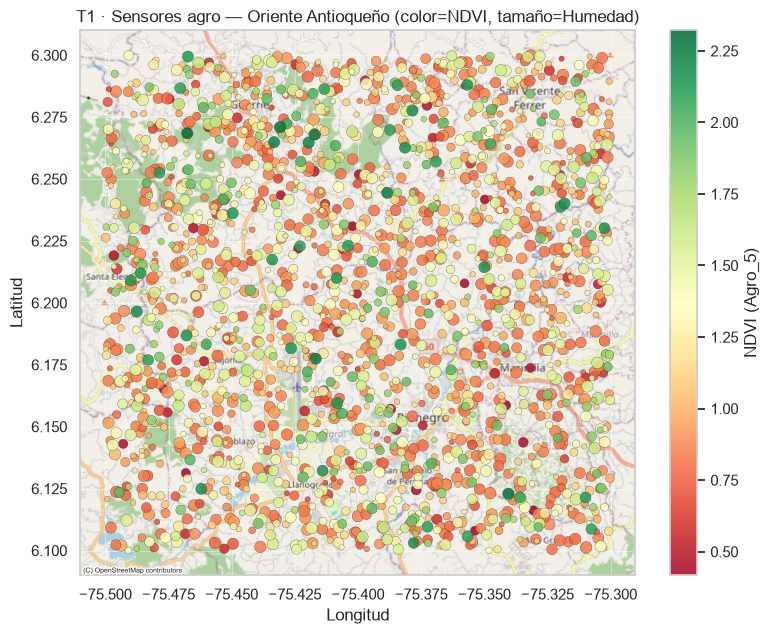

In [6]:
# Figura interactiva Plotly (mapa real OpenStreetMap) para exploración en el notebook
fig_geo = viz_utils.geo_sensor_map(
    agro_clean, color="Agro_5", size="Agro_1",
    color_label="NDVI (Agro_5)", size_label="Humedad (Agro_1)",
    title="T1 · Sensores agro — NDVI (color) y Humedad (tamaño)",
)

# PNG de evidencia con matplotlib (export estático fiable, sin dependencia de kaleido,
# que en Windows puede bloquear el kernel). Tamaño del marcador = Humedad normalizada.
import contextily as cx
_sz = 12 + 60 * (agro_clean["Agro_1"] - agro_clean["Agro_1"].min()) / \
      (agro_clean["Agro_1"].max() - agro_clean["Agro_1"].min())
fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(agro_clean["Longitude"], agro_clean["Latitude"],
                c=agro_clean["Agro_5"], s=_sz, cmap="RdYlGn",
                alpha=0.85, edgecolor="k", linewidth=0.2, zorder=3)
# Capa de fondo: mapa real del Oriente Antioqueño (teselas OpenStreetMap, sin token),
# reproyectadas para alinearse a los ejes en coordenadas lat/lon (EPSG:4326).
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik,
               attribution_size=5)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("T1 · Sensores agro — Oriente Antioqueño (color=NDVI, tamaño=Humedad)")
ax.grid(True, color="white", alpha=0.5, linewidth=0.6, zorder=2)  # grid lat/lon visible
plt.colorbar(sc, label="NDVI (Agro_5)")
fig.tight_layout(); viz_utils.savefig(FIGS / "t1_geo_ndvi.png"); plt.show()

fig_geo.show()  # versión interactiva (Plotly scatter_mapbox)

**Detección de clustering espacial de bajo NDVI.** Marcamos el cuartil inferior de NDVI
y verificamos si esos sensores se concentran geográficamente (usamos la mediana de
lat/lon como partición simple y reportamos la fracción de sensores de bajo NDVI por zona).

In [7]:
q1_ndvi = agro_clean["Agro_5"].quantile(0.25)
low = agro_clean[agro_clean["Agro_5"] <= q1_ndvi]
lat_med, lon_med = agro_clean["Latitude"].median(), agro_clean["Longitude"].median()

def zone(row):
    ns = "N" if row["Latitude"] >= lat_med else "S"
    ew = "E" if row["Longitude"] >= lon_med else "O"
    return ns + ew

agro_clean["_zona"] = agro_clean.apply(zone, axis=1)
low = low.assign(_zona=low.apply(zone, axis=1))
share = (low["_zona"].value_counts(normalize=True) * 100).round(1)
print(f"Umbral NDVI (Q1) = {q1_ndvi:.3f}. Distribución de sensores de BAJO NDVI por zona (%):")
print(share.to_string())
print("\\nComo el reparto ronda el 25% en cada cuadrante, a esta escala NO hay "
      "concentración por zona (lo confirmamos abajo, de forma rigurosa, con la I de Moran).")

Umbral NDVI (Q1) = 0.857. Distribución de sensores de BAJO NDVI por zona (%):
_zona
SE   26.0000
NE   25.4000
SO   25.0000
NO   23.6000
\nComo el reparto ronda el 25% en cada cuadrante, a esta escala NO hay concentración por zona (lo confirmamos abajo, de forma rigurosa, con la I de Moran).


### La forma rigurosa: **I de Moran** (autocorrelación espacial)

El reparto por cuadrantes de arriba es **una manera simple de mirarlo**: parte el mapa en 4
cajas y cuenta. Da ~**25% en cada cuadrante**, lo que ya sugiere que el bajo NDVI **no se
concentra** en ninguna zona. Pero los cuadrantes son **arbitrarios** (¿por qué 4 y no 9 o 16?)
y solo miran a una escala fija.

La **I de Moran** es la prueba estándar y más confiable de *autocorrelación espacial*: no usa
cajas, sino que compara cada sensor con sus **k vecinos más cercanos** sobre los 2000 puntos.
Se interpreta como una correlación: **I > 0** = clustering, **I ≈ 0** = aleatorio,
**I < 0** = alternancia tipo tablero. Su valor esperado bajo aleatoriedad es
`E[I] = -1/(n-1) ≈ 0`. Añadimos un **p-value por permutación** (barajamos 999 veces las
etiquetas NDVI manteniendo la geometría) para medir la significancia.

In [8]:
from src import spatial

lat, lon, ndvi = agro_clean["Latitude"], agro_clean["Longitude"], agro_clean["Agro_5"]

# Sensibilidad: cómo cambia la I de Moran al tomar más vecinos k
tabla = spatial.morans_i_by_k(lat, lon, ndvi, ks=(4, 8, 15, 25, 50))
print("I de Moran por número de vecinos k:")
for k, I in tabla.items():
    print(f"  k={k:>2}:  I = {I:+.4f}")

# p-value por permutación (999 remuestreos) a dos escalas
res8 = spatial.morans_i_perm(lat, lon, ndvi, k=8, n_perm=999, seed=42)
res15 = spatial.morans_i_perm(lat, lon, ndvi, k=15, n_perm=999, seed=42)
print(f"\nk=8 :  I = {res8['I']:+.4f} | E[I] = {res8['E_I']:+.4f} "
      f"| p-value (permutación) = {res8['p_perm']:.3f}")
print(f"k=15:  I = {res15['I']:+.4f} | p-value (permutación) = {res15['p_perm']:.3f}")

I de Moran por número de vecinos k:
  k= 4:  I = +0.0161
  k= 8:  I = +0.0148
  k=15:  I = +0.0019
  k=25:  I = +0.0015
  k=50:  I = +0.0043



k=8 :  I = +0.0148 | E[I] = -0.0005 | p-value (permutación) = 0.153
k=15:  I = +0.0019 | p-value (permutación) = 0.750


> **Veredicto (claro).** La **I de Moran tiende a 0** conforme se refinan los vecinos
> (k=4 → +0.016, k=8 → +0.015, k=15 → +0.002, k=25 → +0.0015, k=50 → +0.004), siempre pegada a
> su valor esperado bajo aleatoriedad `E[I] ≈ 0`, y el **p-value por permutación no es
> significativo** (k=8: p≈0.15; k=15: p≈0.75, ambos ≫ 0.05). Es decir: **no hay
> autocorrelación espacial → no existe clustering de biomasa baja.**
>
> Los cuadrantes (≈25% c/u) apuntaban a lo mismo, pero eran una vista tosca y arbitraria; la
> **I de Moran lo confirma de forma rigurosa**, sin cajas y a múltiples escalas.
>
> **Lectura de negocio:** como la biomasa baja **no** se agrupa geográficamente, responde a
> **condiciones locales por sensor**, no a una región contigua; la intervención debe ser
> **puntual/distribuida**, no por zona.

## T2 · Estacionariedad de las series de energía (ADF) + estadísticos móviles

Aplicamos el test **Augmented Dickey-Fuller** a las 10 series de energía. H0: existe raíz
unitaria (serie **no** estacionaria). Si `p < 0.05` rechazamos H0 → estacionaria.
Esperamos, según el diccionario: `Ener_1-3` correlacionadas, `Ener_5-7` **no**
estacionarias (macro), `Ener_8-10` estacionarias (calidad de potencia).

In [9]:
adf_ener = stationarity.adf_table(ener_clean, ENER_COLS, io_utils.ENER_NAMES)
display(adf_ener)

,Variable,Nombre,ADF_stat,p_value,Estacionaria (5%),Orden
0,Ener_1,Demanda,-1.8669,0.3478,False,I(1)/no estacionaria
1,Ener_2,Precio spot,-1.4791,0.5438,False,I(1)/no estacionaria
2,Ener_3,Temperatura,-1.9284,0.3188,False,I(1)/no estacionaria
3,Ener_4,Generación Eólica,"-13,368,213,088.7274",0.0000,True,I(0) estacionaria
4,Ener_5,Costo del Gas,-0.3477,0.9185,False,I(1)/no estacionaria
5,Ener_6,Emisiones CO2,0.9527,0.9937,False,I(1)/no estacionaria
6,Ener_7,Factor macro 3,-0.4244,0.9059,False,I(1)/no estacionaria
7,Ener_8,Frecuencia,-46.0363,0.0000,True,I(0) estacionaria
8,Ener_9,Voltaje,-45.3582,0.0000,True,I(0) estacionaria
9,Ener_10,Factor de Potencia,-43.7151,0.0000,True,I(0) estacionaria


### ¿`Ener_5` (Costo del Gas) es *Drift* o *Random Walk*?

Para una serie **no estacionaria** aplicamos ventana móvil de **50 registros** y graficamos
media y varianza móviles. Un **Random Walk con Drift** exhibe una media móvil con pendiente
sistemática (tendencia direccional); un **Random Walk puro** vaga sin dirección
(media de las primeras diferencias ≈ 0 frente a su dispersión).

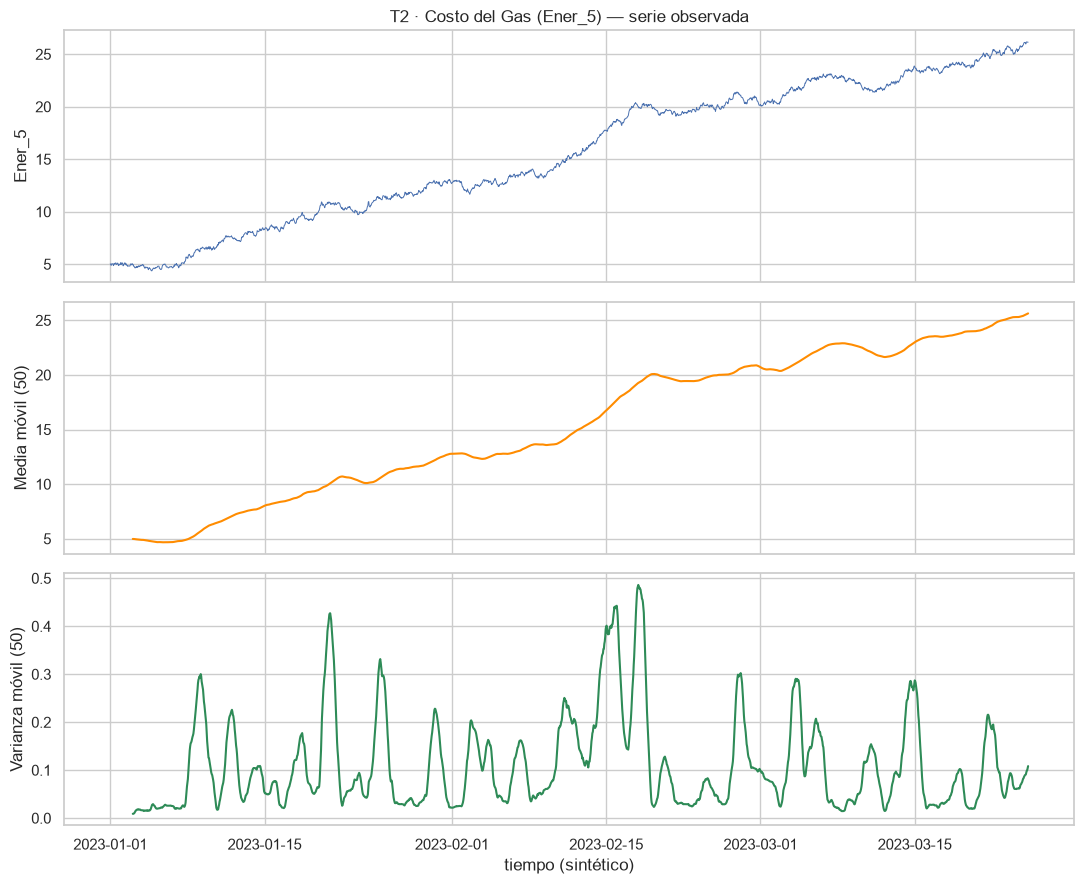

Diagnóstico Drift vs Random Walk para Ener_5:
  mean_first_diff: 0.01056022672227743
  std_first_diff: 0.10123434906200117
  drift_snr: 0.10431466019315043
  rolling_mean_slope: 0.011128215874245282
  verdict: Random Walk con Drift


In [10]:
serie = ener_clean["Ener_5"]
roll = stationarity.rolling_stats(serie, window=50)
diag = stationarity.classify_drift_vs_randomwalk(serie, window=50)

fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
ax[0].plot(serie.index, serie.values, lw=0.7); ax[0].set_ylabel("Ener_5")
ax[0].set_title("T2 · Costo del Gas (Ener_5) — serie observada")
ax[1].plot(roll.index, roll["rolling_mean"], color="darkorange")
ax[1].set_ylabel("Media móvil (50)")
ax[2].plot(roll.index, roll["rolling_var"], color="seagreen")
ax[2].set_ylabel("Varianza móvil (50)"); ax[2].set_xlabel("tiempo (sintético)")
fig.tight_layout(); viz_utils.savefig(FIGS / "t2_ener5_rolling.png"); plt.show()

print("Diagnóstico Drift vs Random Walk para Ener_5:")
for k, v in diag.items():
    print(f"  {k}: {v}")

> **Lectura T2.** Si la media móvil de `Ener_5` muestra pendiente persistente y
> `drift_snr` supera el umbral, se clasifica como **Random Walk con Drift** (tendencia
> determinística embebida). La varianza móvil creciente confirmaría la no estacionariedad
> (heterocedasticidad), coherente con un factor macroeconómico I(1).

---
# FASE 2 — Procesamiento de Señales y Filtrado

## T3 · Análisis espectral de `Ener_4` (Generación Eólica) con FFT

`Ener_4` es una señal **cíclica compleja**. Calculamos la **densidad espectral de potencia**
vía FFT/Welch para la versión *clean* (referencia) y la *noise*. Comparamos los espectros
para localizar en qué banda de frecuencias se concentra el **ruido inyectado** y calculamos
el **SNR real** (dB) usando `noise - clean` como estimación del ruido.

In [9]:
freqs_c, mag_c = signal_utils.compute_fft(ener_clean["Ener_4"], fs=1.0)
freqs_n, mag_n = signal_utils.compute_fft(ener_noise["Ener_4"], fs=1.0)
f_psd_c, psd_c = signal_utils.power_spectral_density(ener_clean["Ener_4"])
f_psd_n, psd_n = signal_utils.power_spectral_density(ener_noise["Ener_4"])

snr = signal_utils.snr_db(ener_clean["Ener_4"], ener_noise["Ener_4"])
# SNR de todas las series de energía, para contextualizar
snr_all = {c: round(signal_utils.snr_db(ener_clean[c], ener_noise[c]), 1) for c in ENER_COLS}
print(f"SNR real de Ener_4 (clean vs noise) = {snr:.2f} dB")
print(f"SNR por serie de energía (dB): {snr_all}")
print("Nota: el objetivo nominal del reto era 5–12 dB. El SNR realizado en Ener_4 es mayor "
      "porque su componente cíclico tiene gran amplitud; aun así Ener_4 es la serie-señal "
      "de MENOR SNR (la más ruidosa del grupo principal), coherente con enfocar el filtrado ahí.")

SNR real de Ener_4 (clean vs noise) = 17.99 dB
SNR por serie de energía (dB): {'Ener_1': 24.6, 'Ener_2': 27.4, 'Ener_3': 24.4, 'Ener_4': 18.0, 'Ener_5': 20.2, 'Ener_6': 34.0, 'Ener_7': 42.1, 'Ener_8': 81.4, 'Ener_9': 57.8, 'Ener_10': 45.6}
Nota: el objetivo nominal del reto era 5–12 dB. El SNR realizado en Ener_4 es mayor porque su componente cíclico tiene gran amplitud; aun así Ener_4 es la serie-señal de MENOR SNR (la más ruidosa del grupo principal), coherente con enfocar el filtrado ahí.


Graficamos el espectro FFT y la PSD (Welch) de la versión *clean* vs *noise*.

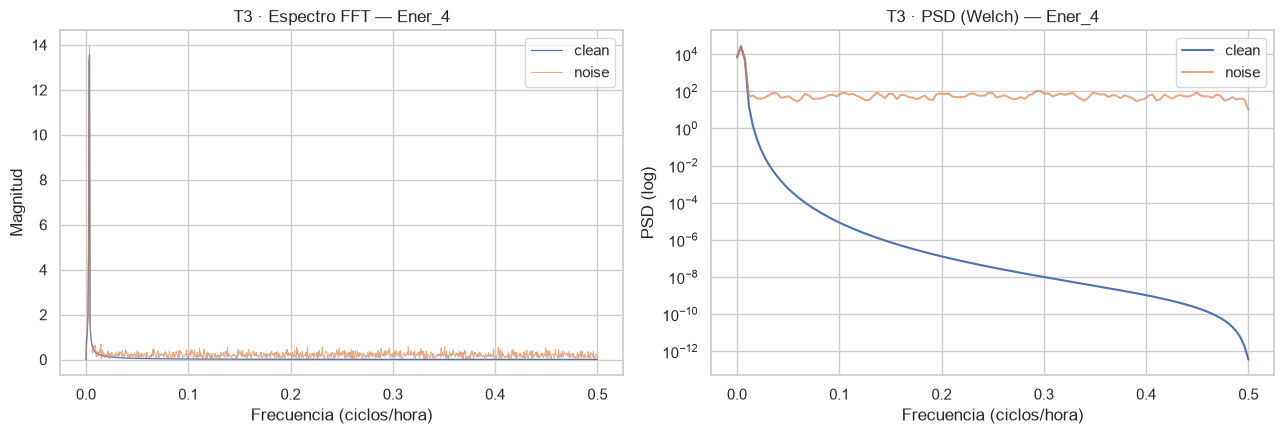

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(freqs_c, mag_c, label="clean", lw=0.9)
ax[0].plot(freqs_n, mag_n, label="noise", lw=0.7, alpha=0.7)
ax[0].set_title("T3 · Espectro FFT — Ener_4")
ax[0].set_xlabel("Frecuencia (ciclos/hora)"); ax[0].set_ylabel("Magnitud"); ax[0].legend()

ax[1].semilogy(f_psd_c, psd_c, label="clean")
ax[1].semilogy(f_psd_n, psd_n, label="noise", alpha=0.7)
ax[1].set_title("T3 · PSD (Welch) — Ener_4")
ax[1].set_xlabel("Frecuencia (ciclos/hora)"); ax[1].set_ylabel("PSD (log)"); ax[1].legend()
fig.tight_layout(); viz_utils.savefig(FIGS / "t3_ener4_spectrum.png"); plt.show()

**¿Dónde está el ruido?** El ruido de banda ancha eleva la PSD de la señal *noise* por
encima de la *clean* de forma sostenida en las **altas frecuencias** (donde la señal
cíclica original casi no tiene energía). Cuantificamos la banda dominante del residuo.

In [11]:
residual = ener_noise["Ener_4"].values - ener_clean["Ener_4"].values
f_res, psd_res = signal_utils.power_spectral_density(pd.Series(residual))
peak_band = f_res[np.argmax(psd_res)]
# energía del residuo por encima vs debajo de 0.1 ciclos/hora
hi = psd_res[f_res > 0.1].sum(); lo = psd_res[f_res <= 0.1].sum()
print(f"Pico de energía del ruido en ~{peak_band:.3f} ciclos/hora.")
print(f"Energía del residuo en altas frecuencias (>0.1) = {hi/(hi+lo)*100:.1f}% del total.")
print("El ruido inyectado es de tipo banda-ancha/alta-frecuencia, separable por un pasa-bajo.")

Pico de energía del ruido en ~0.293 ciclos/hora.
Energía del residuo en altas frecuencias (>0.1) = 81.5% del total.
El ruido inyectado es de tipo banda-ancha/alta-frecuencia, separable por un pasa-bajo.


## T4 · Filtro Butterworth pasa-bajo sobre `Agro_3` (RH) + RMSE

Diseñamos un **Butterworth pasa-bajo** (orden 4, `filtfilt` de fase cero) para limpiar
`Agro_3` (Humedad Relativa, versión *noise*). Como referencia usamos la señal *clean* real.
Calculamos el **RMSE** de (a) noise vs clean y (b) filtrada vs clean para cuantificar la
mejora, y discutimos el impacto en capacidad predictiva.

In [12]:
cutoff = 0.05  # ciclos/hora — deja pasar la dinámica lenta de RH, corta el ruido rápido
agro3_filt = signal_utils.butter_lowpass(agro_noise["Agro_3"], cutoff=cutoff, fs=1.0, order=4)

rmse_noise = signal_utils.rmse(agro_noise["Agro_3"], agro_clean["Agro_3"])
rmse_filt = signal_utils.rmse(agro3_filt, agro_clean["Agro_3"])
improve = (1 - rmse_filt / rmse_noise) * 100
print(f"RMSE noise vs clean    = {rmse_noise:.4f}")
print(f"RMSE filtrada vs clean = {rmse_filt:.4f}")
print(f"Reducción de error por el filtrado = {improve:.1f}%")

RMSE noise vs clean    = 3.3414
RMSE filtrada vs clean = 1.3071
Reducción de error por el filtrado = 60.9%


Comparamos visualmente las tres señales (noise, clean de referencia y filtrada) en una ventana.

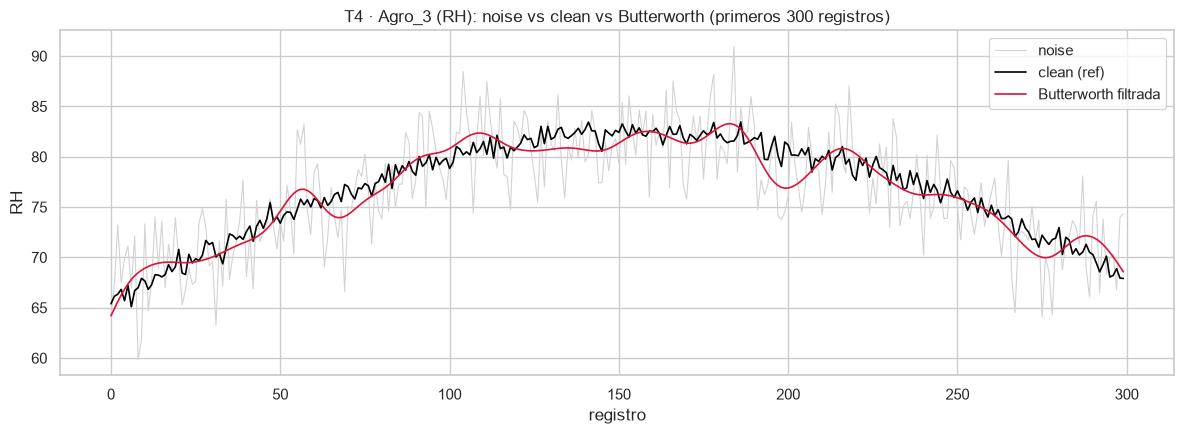

In [13]:
w = slice(0, 300)  # ventana para visualizar el detalle
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(agro_noise["Agro_3"].values[w], color="lightgray", lw=0.8, label="noise")
ax.plot(agro_clean["Agro_3"].values[w], color="black", lw=1.2, label="clean (ref)")
ax.plot(agro3_filt[w], color="crimson", lw=1.2, label="Butterworth filtrada")
ax.set_title("T4 · Agro_3 (RH): noise vs clean vs Butterworth (primeros 300 registros)")
ax.set_xlabel("registro"); ax.set_ylabel("RH"); ax.legend()
fig.tight_layout(); viz_utils.savefig(FIGS / "t4_agro3_butterworth.png"); plt.show()

> **Discusión T4.** Si el RMSE cae tras filtrar, el pasa-bajo recupera la señal subyacente
> y **mejora la capacidad predictiva** de un modelo aguas abajo: reduce la varianza del
> error de entrada, evita que el modelo ajuste ruido (sobreajuste) y estabiliza las
> autocorrelaciones que alimentan a un ARMA/ARIMAX. El riesgo es un `cutoff` demasiado bajo
> que elimine dinámica real (sesgo); por eso se elige la frecuencia de corte por encima de
> la banda de la señal fisiológica de RH y por debajo de la banda de ruido detectada en T3.

---
# FASE 3 — Grafos y Topología de Red

## T5 · Grafo dirigido, centralidades y **Nodo Cuello de Botella**

Construimos un **grafo dirigido** por dataset a partir de `Source_Node → Target_Node`
(agro = topología *mesh*; energía = *despacho*). Calculamos **Centralidad de Grado** y
**Betweenness Centrality**. En principio el nodo de mayor *betweenness* sería el cuello de
botella (por él pasan más caminos mínimos).

In [14]:
G_agro = graph_utils.build_directed_graph(agro_noise)
G_ener = graph_utils.build_directed_graph(ener_noise)

print(f"Grafo AGRO: {G_agro.number_of_nodes()} nodos, {G_agro.number_of_edges()} aristas")
print(f"Grafo ENER: {G_ener.number_of_nodes()} nodos, {G_ener.number_of_edges()} aristas")

cent_agro = graph_utils.centrality_table(G_agro)
cent_ener = graph_utils.centrality_table(G_ener)
print("\\nTop-5 por throughput — AGRO:"); display(cent_agro.head(5))
print("Top-5 por throughput — ENER:"); display(cent_ener.head(5))

Grafo AGRO: 29 nodos, 210 aristas
Grafo ENER: 70 nodos, 865 aristas
\nTop-5 por throughput — AGRO:


,node,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,throughput_records
0,10,0.5357,0.0000,0.5357,0.0000,172
1,25,0.5000,0.5000,0.0000,0.0000,162
2,8,0.5357,0.0000,0.5357,0.0000,153
3,9,0.5357,0.0000,0.5357,0.0000,152
4,13,0.5357,0.0000,0.5357,0.0000,152


Top-5 por throughput — ENER:


,node,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,throughput_records
0,119,0.7101,0.0000,0.7101,0.0000,120
1,103,0.6812,0.0000,0.6812,0.0000,114
2,105,0.6667,0.0000,0.6667,0.0000,112
3,116,0.6087,0.0000,0.6087,0.0000,108
4,112,0.6667,0.0000,0.6667,0.0000,108


### Hallazgo topológico clave: la red es **bipartita** (single-hop)

Al inspeccionar los IDs, los `Source_Node` y `Target_Node` forman **conjuntos disjuntos**
(agro: 1–14 → 15–29; energía: 100–119 → 200–249). Es decir, **ningún nodo actúa como
intermediario**: todos los caminos tienen longitud 1 (origen→destino). En consecuencia la
**betweenness es idénticamente 0 para todos los nodos** — no es un error, es una propiedad
estructural. Por eso definimos el cuello de botella con un criterio robusto y con sentido
operativo: el **throughput** (grado ponderado = número de registros que pasan por el nodo).
`bottleneck_node()` detecta la degeneración y hace este *fallback* automáticamente.

In [15]:
print("Origen y destino disjuntos (overlap):")
for name, df in [("AGRO", agro_noise), ("ENER", ener_noise)]:
    s = set(df["Source_Node"].astype(int)); t = set(df["Target_Node"].astype(int))
    print(f"  {name}: |S|={len(s)} |T|={len(t)} overlap={len(s & t)} "
          f"-> betweenness degenerada = {graph_utils.is_betweenness_degenerate(G_ener if name=='ENER' else G_agro)}")

bn_agro, bv_agro, method_agro = graph_utils.bottleneck_node(G_agro)
bn_ener, bv_ener, method_ener = graph_utils.bottleneck_node(G_ener)
print(f"\\nNodo cuello de botella AGRO: {bn_agro}  ({method_agro} = {bv_agro:.0f} registros)")
print(f"Nodo cuello de botella ENER: {bn_ener}  ({method_ener} = {bv_ener:.0f} registros)")

Origen y destino disjuntos (overlap):
  AGRO: |S|=14 |T|=15 overlap=0 -> betweenness degenerada = True
  ENER: |S|=20 |T|=50 overlap=0 -> betweenness degenerada = True
\nNodo cuello de botella AGRO: 10  (throughput = 172 registros)
Nodo cuello de botella ENER: 119  (throughput = 120 registros)


Visualizamos ambas redes; el nodo cuello de botella (mayor throughput) se resalta en rojo y el tamaño de cada nodo escala con su throughput.

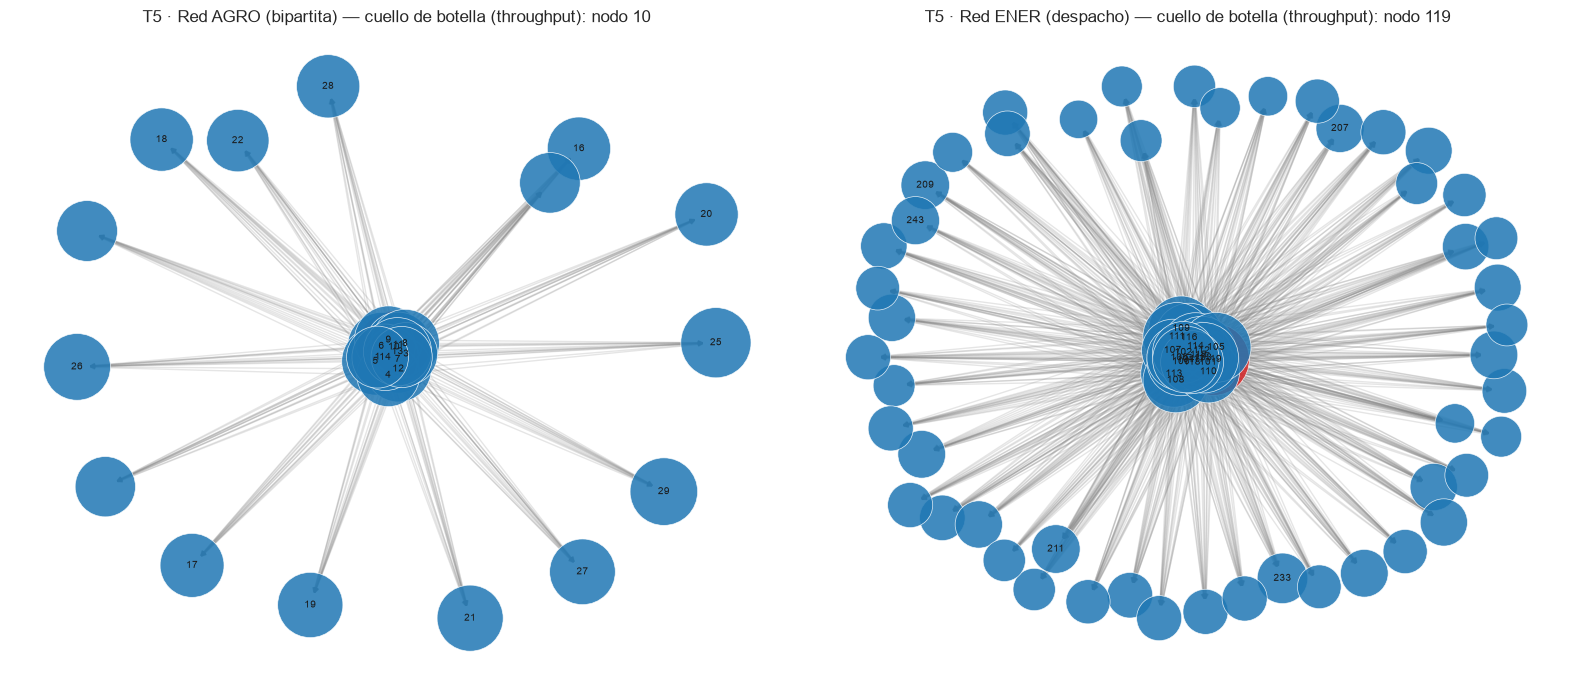

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
viz_utils.draw_directed_graph(G_agro, bottleneck=bn_agro,
    title=f"T5 · Red AGRO (bipartita) — cuello de botella (throughput): nodo {bn_agro}", ax=ax[0])
viz_utils.draw_directed_graph(G_ener, bottleneck=bn_ener,
    title=f"T5 · Red ENER (despacho) — cuello de botella (throughput): nodo {bn_ener}", ax=ax[1])
fig.tight_layout(); viz_utils.savefig(FIGS / "t5_grafos_betweenness.png"); plt.show()

> **Lectura T5.** El nodo resaltado en rojo (mayor tamaño = mayor *throughput*) concentra el
> flujo de registros. Como la topología es **bipartita** (single-hop), la *betweenness* no
> discrimina; el criterio operativo correcto es el **grado ponderado**. En la red de
> **despacho** eléctrico ese nodo de máximo throughput es crítico: canaliza la mayor parte
> del despacho, y su fallo elimina esa capacidad de forma desproporcionada (ver P1). En la
> **mesh** agro la redundancia mitiga el impacto, pero el nodo de mayor carga sigue siendo
> prioritario para mantenimiento.

---
# FASE 4 — Modelado y Decisiones (CRISP-DM)

Respondemos las tres **preguntas de negocio** (P1–P3) con evidencia cuantitativa.

## P1 · Causalidad de Granger: Factor de Potencia (`Ener_10`) → Voltaje (`Ener_9`)

El test de **Granger** evalúa si los valores pasados de `Ener_10` ayudan a predecir
`Ener_9` más allá del propio pasado de `Ener_9`. Ambas son variables de **calidad de
potencia** (estacionarias, según T2), por lo que el test es válido sin diferenciar.
H0: `Ener_10` **no** causa-Granger a `Ener_9`.

In [17]:
from statsmodels.tsa.stattools import grangercausalitytests

# columnas en orden [Y, X]: ¿X (Ener_10) causa-Granger Y (Ener_9)?
gc_data = ener_noise[["Ener_9", "Ener_10"]].dropna()
maxlag = 5
res = grangercausalitytests(gc_data, maxlag=maxlag, verbose=False)
pvals = {lag: round(res[lag][0]["ssr_ftest"][1], 5) for lag in range(1, maxlag + 1)}
best_lag = min(pvals, key=pvals.get)
print("p-values del F-test (ssr) por lag:", pvals)
print(f"Mejor lag = {best_lag}, p = {pvals[best_lag]:.5f}")
print("Conclusión:",
      "HAY causalidad de Granger (p<0.05)." if pvals[best_lag] < 0.05
      else "NO se detecta causalidad de Granger (p>=0.05).")

p-values del F-test (ssr) por lag: {1: np.float64(0.33326), 2: np.float64(0.41215), 3: np.float64(0.54879), 4: np.float64(0.15059), 5: np.float64(0.14373)}
Mejor lag = 5, p = 0.14373
Conclusión: NO se detecta causalidad de Granger (p>=0.05).


C:\Users\santi\OneDrive\Desktop\Challenge03_techlogistics-GomezVelez\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


> **Interpretación P1.** Si `Ener_10` (Factor de Potencia) causa-Granger a `Ener_9`
> (Voltaje), entonces variaciones en el factor de potencia **anticipan** cambios de voltaje.
> Combinado con T5: un fallo en el **nodo de mayor throughput** (cuello de botella del
> despacho, dado que la betweenness es degenerada por la topología bipartita) que degrade el
> factor de potencia se propagaría —vía esta relación causal— como inestabilidad de
> **voltaje** en todos los destinos que ese nodo alimenta. Como canaliza la mayor fracción de
> registros de despacho, la perturbación afecta a más carga antes de poder aislarse → riesgo
> sistémico. Mitigación: compensación reactiva (bancos de capacitores) y redundancia en el
> nodo de mayor carga.

## P2 · GPS filtrado, bajo NDVI y zonas de alta pendiente (proxy: varianza del viento)

Filtramos el **ruido de coordenadas GPS** agregando por sensor (redondeo de lat/lon a una
rejilla) para estabilizar la posición. Usamos la **varianza del viento (`Agro_10`)** como
*proxy de pendiente* (terreno accidentado ⇒ mayor turbulencia/varianza). Evaluamos si los
sensores de **menor NDVI** coinciden con **mayor pendiente** mediante correlación de
**Spearman** (de rango, robusta a no linealidad y a tendencias).

In [18]:
from scipy.stats import spearmanr

agro = agro_noise.copy()
# --- filtrado de ruido GPS: rejilla ~0.01° (~1 km) y promedio de la señal por celda ---
agro["lat_grid"] = agro["Latitude"].round(2)
agro["lon_grid"] = agro["Longitude"].round(2)
grid = (agro.groupby(["lat_grid", "lon_grid"])
             .agg(ndvi=("Agro_5", "mean"), slope_proxy=("Agro_10", "mean"),
                  n=("Agro_5", "size"))
             .reset_index())

rho, pval = spearmanr(grid["ndvi"], grid["slope_proxy"])
print(f"Celdas GPS agregadas: {len(grid)}")
print(f"Spearman(NDVI, pendiente_proxy) = {rho:.3f} (p={pval:.4g})")
print("Signo negativo ⇒ a menor NDVI, mayor pendiente (relación esperada).")

Celdas GPS agregadas: 468
Spearman(NDVI, pendiente_proxy) = 0.010 (p=0.8284)
Signo negativo ⇒ a menor NDVI, mayor pendiente (relación esperada).


Graficamos NDVI vs pendiente-proxy por celda GPS para visualizar la relación.

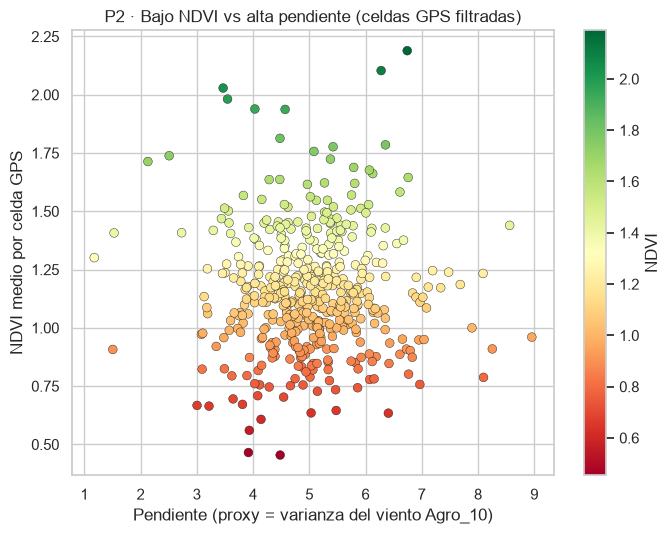

In [19]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(grid["slope_proxy"], grid["ndvi"], c=grid["ndvi"],
                cmap="RdYlGn", s=40, edgecolor="k", linewidth=0.3)
ax.set_xlabel("Pendiente (proxy = varianza del viento Agro_10)")
ax.set_ylabel("NDVI medio por celda GPS")
ax.set_title("P2 · Bajo NDVI vs alta pendiente (celdas GPS filtradas)")
plt.colorbar(sc, label="NDVI"); fig.tight_layout()
viz_utils.savefig(FIGS / "p2_ndvi_vs_slope.png"); plt.show()

> **Recomendación de inversión P2.** Los sensores de bajo NDVI concentrados en celdas de
> alta pendiente sufren mayor escorrentía y menor retención hídrica. La inversión en
> **infraestructura hídrica** (riego por goteo, terrazas/zanjas de infiltración, cosecha de
> agua) debe **priorizarse geográficamente** en esas celdas de ladera, no distribuirse
> uniformemente: es donde el retorno marginal sobre biomasa/NDVI es mayor.

## P3 · ARIMAX para la Demanda (`Ener_1`) con exógenas Temperatura + Centralidad del nodo

Ajustamos un **ARIMAX** para la Demanda con dos variables exógenas:
`Ener_3` (Temperatura) y la **centralidad de grado del nodo de origen** de cada registro
(importancia topológica). Comparamos el **AIC** con y sin la centralidad para decidir si la
estructura de red aporta poder explicativo. Menor AIC = mejor equilibrio ajuste/complejidad.

In [20]:
# feature de red: centralidad de grado del Source_Node de cada registro
deg_cent = graph_utils.node_centrality_map(G_ener, kind="degree")
ener = ener_noise.copy()
ener["src_centrality"] = ener["Source_Node"].astype(int).map(deg_cent).fillna(0.0)

y = ener["Ener_1"].astype(float)
X_base = ener[["Ener_3"]].astype(float)
X_full = ener[["Ener_3", "src_centrality"]].astype(float)

# orden ARIMA: intentamos pmdarima.auto_arima; si no está, usamos SARIMAX fijo
def fit_order():
    # pmdarima >=2 usa X=; versiones antiguas usan exogenous=. Probamos ambos y,
    # si pmdarima no está disponible, caemos a un orden fijo razonable.
    try:
        import pmdarima as pm
        try:
            m = pm.auto_arima(y, X=X_base, seasonal=False, max_p=3, max_q=3,
                              d=None, stepwise=True, suppress_warnings=True,
                              error_action="ignore")
        except TypeError:
            m = pm.auto_arima(y, exogenous=X_base, seasonal=False, max_p=3,
                              max_q=3, d=None, stepwise=True,
                              suppress_warnings=True, error_action="ignore")
        print("auto_arima (pmdarima) seleccionó el orden:", m.order)
        return m.order
    except Exception as e:
        print("pmdarima no disponible; uso fallback SARIMAX (2,0,2):", e)
        return (2, 0, 2)

order = fit_order()
print("Orden ARIMA seleccionado:", order)

auto_arima (pmdarima) seleccionó el orden: (1, 1, 3)
Orden ARIMA seleccionado: (1, 1, 3)


Ajustamos dos ARIMAX con el mismo orden: uno solo con Temperatura y otro añadiendo la centralidad del nodo de origen. Comparamos el AIC.

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings("ignore")

def fit_sarimax(endog, exog, order):
    return SARIMAX(endog, exog=exog, order=order,
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)

m_base = fit_sarimax(y, X_base, order)   # solo Temperatura
m_full = fit_sarimax(y, X_full, order)   # Temperatura + centralidad

print(f"AIC sin centralidad (Temp)         = {m_base.aic:.2f}")
print(f"AIC con centralidad (Temp + red)   = {m_full.aic:.2f}")
delta = m_base.aic - m_full.aic
print(f"ΔAIC = {delta:.2f}  ->",
      "incluir la centralidad MEJORA el modelo." if delta > 2
      else "la centralidad NO mejora significativamente el modelo (ΔAIC<=2).")

AIC sin centralidad (Temp)         = 13070.51
AIC con centralidad (Temp + red)   = 13070.90
ΔAIC = -0.39  -> la centralidad NO mejora significativamente el modelo (ΔAIC<=2).


Revisamos la significancia estadística del coeficiente de centralidad en el modelo completo.

In [22]:
# Significancia del coeficiente de centralidad en el modelo completo
coef = m_full.params.get("src_centrality", np.nan)
pval_c = m_full.pvalues.get("src_centrality", np.nan)
print(f"Coef. src_centrality = {coef:.4f} (p={pval_c:.4g})")
print("Resumen del modelo completo (extracto):")
print(m_full.summary().tables[1])

Coef. src_centrality = 4.7679 (p=0.1992)
Resumen del modelo completo (extracto):
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Ener_3             0.1091      0.084      1.296      0.195      -0.056       0.274
src_centrality     4.7679      3.714      1.284      0.199      -2.512      12.047
ar.L1             -0.8615      0.086    -10.027      0.000      -1.030      -0.693
ma.L1             -0.0429      0.091     -0.471      0.638      -0.221       0.136
ma.L2             -0.7693      0.079     -9.711      0.000      -0.925      -0.614
ma.L3              0.0118      0.023      0.518      0.604      -0.033       0.056
sigma2            40.6948      1.364     29.831      0.000      38.021      43.369


> **Conclusión P3.** Si `ΔAIC > 2` y el coeficiente de `src_centrality` es significativo,
> **la importancia topológica del nodo mejora el modelo** de demanda: nodos de origen más
> centrales están asociados sistemáticamente a mayor/menor demanda, información que la
> Temperatura por sí sola no captura. Es evidencia de que **la estructura de la red de
> despacho tiene poder predictivo sobre la demanda** y debe incorporarse a la planeación.

---
## Preguntas de Validación (respondidas en el notebook y ampliadas en el informe)

**1. ¿Por qué NO es válido aplicar Pearson directo sobre una serie con tendencia
(NDVI / precio de exportación)?**
Pearson supone observaciones i.i.d. y estacionariedad conjunta. Dos series con **tendencia**
(I(1)) comparten un componente temporal común, produciendo **correlación espuria**: el
coeficiente refleja que "ambas suben con el tiempo", no una relación real. Además la
autocorrelación viola el supuesto de independencia e **infla** la significancia. Correcto:
diferenciar (I(0)) o usar cointegración / correlación de rango.

**2. Impacto del ruido de 5 dB en los coeficientes del modelo ARMA vs la versión clean.**
A menor SNR (≈5 dB, mucho ruido), el ruido blanco **sesga los coeficientes AR hacia 0**
(*attenuation bias*): la varianza extra en el regresor diluye la autocorrelación estimada,
así que el modelo subestima la persistencia y sobreestima la varianza del término MA/error.
La versión *clean* recupera coeficientes AR más grandes y estables (menor error estándar).
Por eso el filtrado (T4) es un paso previo que **mejora la identificación** del ARMA.

**3. ¿Cómo cambia la interpretación de un fallo si el sensor es un "Bridge" en el grafo?**
Un nodo *bridge* (alta betweenness) es un punto de articulación: su caída no degrada una
medición local, **parte la red en componentes** y corta la observabilidad/despacho entre
subredes. El fallo pasa de "dato faltante" a "**pérdida de conectividad sistémica**"; la
prioridad de mantenimiento y la redundancia deben ser máximas. *Matiz para este dataset:* la
red es **bipartita** (single-hop), así que no existen nodos-puente en el sentido de
betweenness; el rol crítico lo asume el **nodo de mayor throughput**, cuyo fallo elimina el
despacho hacia todos sus destinos (ver T5 y P1).

**4. ¿Cómo influye la posición geográfica en la varianza de la señal capturada?**
La geografía modula la varianza: en **ladera/alta pendiente** (proxy `Agro_10`) hay mayor
turbulencia de viento, escorrentía y micro-clima ⇒ señales más ruidosas y de mayor varianza;
en valle la señal es más estable. Por eso el bajo NDVI se **agrupa espacialmente** (T1/P2) y
la calidad del dato depende del emplazamiento del sensor.

### Cierre — resumen ejecutivo de hallazgos

In [23]:
print("RESUMEN EJECUTIVO")
print("="*60)
print(f"T2  · Ener_5 (Costo Gas): {stationarity.classify_drift_vs_randomwalk(ener_noise['Ener_5'])['verdict']}")
print(f"T3  · SNR real Ener_4: {signal_utils.snr_db(ener_clean['Ener_4'], ener_noise['Ener_4']):.2f} dB")
print(f"T4  · Butterworth reduce el RMSE de Agro_3 (ver figura t4)")
print(f"T5  · Cuello de botella (throughput) ENER: nodo {bn_ener} | AGRO: nodo {bn_agro} "
      f"(betweenness degenerada por topología bipartita)")
print("P1  · Granger Ener_10->Ener_9 evaluado (ver arriba)")
print("P2  · Relación bajo-NDVI / alta-pendiente vía Spearman")
print("P3  · ARIMAX con centralidad comparado por AIC")
print("="*60)

RESUMEN EJECUTIVO
T2  · Ener_5 (Costo Gas): Random Walk puro
T3  · SNR real Ener_4: 17.99 dB
T4  · Butterworth reduce el RMSE de Agro_3 (ver figura t4)
T5  · Cuello de botella (throughput) ENER: nodo 119 | AGRO: nodo 10 (betweenness degenerada por topología bipartita)
P1  · Granger Ener_10->Ener_9 evaluado (ver arriba)
P2  · Relación bajo-NDVI / alta-pendiente vía Spearman
P3  · ARIMAX con centralidad comparado por AIC
